# Base code

In [26]:
import os
import numpy as np
import pandas as pd
from signalAI.experiments.features_1d import ExperimentResults
from scipy.stats import ttest_rel, wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mode


In [27]:
def load_experiment_scores(exp_path, metric_name="accuracy"):
    """
    Loads all rounds from an experiment folder and returns
    a list of metric values (one per round).
    """
    scores = []

    for file in sorted(os.listdir(exp_path)):
        if file.startswith("round") and file.endswith(".json"):
            res = ExperimentResults.load_json(os.path.join(exp_path, file))
            
            # ⚠️ Adjust this line if your metric is stored elsewhere
            for fold in res.folds:
                scores.append(fold.metrics[metric_name])
            

    return np.array(scores)

def heatmap_with_statical_test(BASE_PATH,feature_sets,metric_name="Balanced Accuracy",metric="accuracy"):
    scores_dict = {
        name: load_experiment_scores(os.path.join(BASE_PATH, path), metric_name=metric)
        for name, path in feature_sets.items()
    }
    #scores_dict['MJ VT\nSVM'] = [0.7603070175438595, 0.9292397660818713, 0.9551169590643275, 0.8510233918128656, 0.9484649122807017, 0.8301169590643274, 0.8399853801169591, 0.7568713450292397, 0.9020467836257311, 0.9101608187134503, 0.730921052631579, 0.9040204678362572, 0.9078216374269005, 0.8160087719298246, 0.7807017543859649, 0.916593567251462, 0.8603801169590642, 0.8429093567251462, 0.8221491228070176, 0.895906432748538, 0.8958333333333333, 0.8994883040935673, 0.7415935672514619, 0.9114766081871345, 0.8239035087719297, 0.7554824561403508, 0.8328216374269005, 0.9644005847953215, 0.7943713450292398, 0.9222953216374268, 0.9114766081871345, 0.8142543859649123]
    #scores_dict['MJ VT\nRF+SVM'] = [0.7989766081871345, 0.9238304093567251, 0.9663742690058479, 0.9058479532163742, 0.9651315789473683, 0.8782163742690059, 0.8592836257309941, 0.8069444444444445, 0.9202485380116958, 0.9234649122807017, 0.8144005847953216, 0.8921783625730993, 0.9258040935672514, 0.8468567251461989, 0.8285087719298245, 0.9550438596491229, 0.8725146198830409, 0.8546052631578948, 0.8707602339181287, 0.9038011695906433, 0.9024122807017544, 0.9350877192982456, 0.800219298245614, 0.9260964912280701, 0.8568713450292397, 0.801827485380117, 0.8782163742690058, 0.9708333333333333, 0.8316520467836258, 0.9157163742690059, 0.9220029239766081, 0.8653508771929824]
    #scores_dict['MJ VT\nRF'] = [0.8245614035087719, 0.8915204678362574, 0.9573099415204678, 0.8858187134502924, 0.9470760233918128, 0.8817251461988305, 0.8652777777777777, 0.7910087719298246, 0.9114766081871345, 0.8962719298245614, 0.8307748538011697, 0.8706140350877193, 0.9158625730994152, 0.87046783625731, 0.8044590643274854, 0.9193713450292398, 0.8657894736842104, 0.8634502923976608, 0.8714912280701754, 0.8926900584795321, 0.8968567251461989, 0.8788011695906434, 0.8384502923976608, 0.8949561403508772, 0.8576023391812866, 0.7843567251461989, 0.8633040935672515, 0.9381578947368421, 0.8321637426900584, 0.905921052631579, 0.9040204678362573, 0.8568713450292399]
    feature_names = list(scores_dict.keys())
    n = len(feature_names)

    stat_matrix = np.zeros((n, n))

    feature_names = list(scores_dict.keys())
    n = len(feature_names)

    stat_matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            if i == j:
                stat_matrix[i, j] = np.nan  # diagonal
            elif i < j:
                # Upper triangle → paired t-test
                stat_matrix[i, j] = ttest_rel(
                    scores_dict[feature_names[i]],
                    scores_dict[feature_names[j]]
                ).pvalue
            else:
                # Lower triangle → Wilcoxon
                stat_matrix[i, j] = wilcoxon(
                    scores_dict[feature_names[i]],
                    scores_dict[feature_names[j]]
                ).pvalue
    stat_df = pd.DataFrame(
        stat_matrix,
        index=feature_names,
        columns=feature_names
    )
    alpha= 0.05
    mask = stat_df >= alpha
    annot=False
    labels = stat_df.index.tolist()
    plt.figure(figsize=(9, 7))

    sns.heatmap(
        stat_df,
        cmap="coolwarm_r",
        linewidths=0.5,
        cbar_kws={"label": "p-value"},
        mask=mask
    )
    ax = plt.gca()

    for i, label in enumerate(labels):
        ax.text(
            i + 0.5,
            i + 0.5,
            label,
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="black"
        )
    plt.title(
        f"Statistical Comparison of Feature Sets ({metric_name})\n"
        "Upper: corrected t-test | Lower: Wilcoxon\n"
        "Only significant differences shown (p < 0.05)",
        fontsize=12
    )

    ax.set_xticks([])
    ax.set_yticks([])
    #plt.xticks(rotation=45, ha="right")
    #plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

In [49]:
from sklearn.metrics import balanced_accuracy_score, f1_score


def calcular_votacao_majoritaria(dados_entrada):
    resultados_finais = {}

    for round_name, lista_resultados in dados_entrada.items():
        # Dicionários temporários para agrupar previsões por FOLD
        # Estrutura: { '0': [[pred_modelo_A], [pred_modelo_B], ...], '1': ... }
        preds_por_fold = {}
        trues_por_fold = {} 

        # --- Passo 1: Agrupar as predições de todos os modelos por Fold ---
        for item in lista_resultados:
            # item é algo como {'0': {'y_pred':...}}
            for fold_id, conteudo in item.items():
                if fold_id not in preds_por_fold:
                    preds_por_fold[fold_id] = []
                    # Guardamos o y_true apenas uma vez (assume-se que é igual para todos)
                    trues_por_fold[fold_id] = conteudo['y_true']
                
                preds_por_fold[fold_id].append(conteudo['y_pred'])

        # --- Passo 2: Calcular a Moda (Votação) ---
        resultados_finais[round_name] = {}
        
        for fold_id, lista_de_preds in preds_por_fold.items():
            # Converte para matriz numpy: (num_modelos, num_amostras)
            matriz_votos = np.array(lista_de_preds)
            
            # scipy.stats.mode calcula o valor mais frequente ao longo do eixo 0 (colunas)
            # keepdims=False retorna arrays unidimensionais diretamente
            resultado_voto, _ = mode(matriz_votos, axis=0, keepdims=False)
            
            resultados_finais[round_name][fold_id] = {
                'y_pred': resultado_voto.tolist(), # Converte de volta para lista Python
                'y_true': trues_por_fold[fold_id]
            }
            
    return resultados_finais

def calcular_metricas(dados_votados):
    lista_metricas = []

    for round_name, folds_data in dados_votados.items():
        for fold_id, conteudo in folds_data.items():
            y_true = conteudo['y_true']
            y_pred = conteudo['y_pred']

            # Cálculo das métricas
            # zero_division=0 evita erros caso o modelo não preveja nenhuma classe existente no y_true
            f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
            bal_acc = balanced_accuracy_score(y_true, y_pred)

            # Organizando o resultado
            resultado_fold = {
                'round': round_name,
                'fold': fold_id,
                'f1_macro': f1,
                'balanced_accuracy': bal_acc
            }
            
            lista_metricas.append(resultado_fold)

    return lista_metricas

def ENSEMBLE_RESULTS(exp_paths, BASE_PATH):
    """
    Loads all rounds from an experiment folder and returns
    a list of metric values (one per round).
    """
    rounds =  {}
    
    for exp_path in exp_paths:
        exp_path = os.path.join(BASE_PATH, exp_path)
        for file in sorted(os.listdir(exp_path)):
            if file.startswith("round") and file.endswith(".json"):
                res = ExperimentResults.load_json(os.path.join(exp_path, file))
                if file not in rounds:
                    rounds[file] = []
          
            for fold in res.folds:
                rounds[file].append({fold.fold_index:{'y_pred': fold.y_pred, 'y_true': fold.y_true}})
            
                
    resultado = calcular_votacao_majoritaria(rounds)
    metricas_folds = calcular_metricas(resultado)
    return metricas_folds

def ENSEMBLE_RESULTS_SINGLEROUND(exp_paths,BASE_PATH):
    """
    Loads all rounds from an experiment folder and returns
    a list of metric values (one per round).
    """
    rounds =  {}
    
    for exp_path in exp_paths:
        exp_path = os.path.join(BASE_PATH, exp_path)
        if exp_path.endswith(".json"):
            res = ExperimentResults.load_json(exp_path)
            if exp_path not in rounds:
                rounds[exp_path] = []
        
        for fold in res.folds:
            rounds[exp_path].append({fold.fold_index:{'y_pred': fold.y_pred, 'y_true': fold.y_true}})
            
                
    resultado = calcular_votacao_majoritaria(rounds)
    metricas_folds = calcular_metricas(resultado)
    return metricas_folds

# CWRU 12K

In [50]:
BASE_PATH_CWRU12k = "/home/vbbonella/mestrado/tese-mestrado/experiments_scripts/results_per_dataset/cwru12k"

feature_sets_cwru12k = {
    "RF\nTime": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_12K_time_20251031_173422",
    "RF\nFFT": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_12K_frequency_20251031_174616",
    "RF\nPSD": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_12K_psd_20251031_182742",
    "RF\nEnvelope": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_12K_spectral_envelope_20251031_183741",
    "RF\nWavelet": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_12K_wavelet_20251031_180927",
    "RF\nT&F": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_12K_time_and_frequency_20251031_175612",
    "RF\nAll": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_12K_all_20251031_184819",
    "SVM\nTime": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_12K_time_20251031_135932",
    "SVM\nFFT": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_12K_frequency_20251031_140314",
    "SVM\nPSD": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_12K_psd_20251031_141513",
    "SVM\nEnvelope": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_12K_spectral_envelope_20251031_141836",
    "SVM\nWavelet": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_12K_wavelet_20251031_141047",
    "SVM\nT&F": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_12K_time_and_frequency_20251031_140638",
    "SVM\nAll": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_12K_all_20251031_142153"
}

feature_sets_rf_svm_cwru12k = {
    "RF\nTime": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_12K_time_20251031_173422",
    "RF\nFFT": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_12K_frequency_20251031_174616",
    "RF\nPSD": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_12K_psd_20251031_182742",
    "RF\nEnvelope": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_12K_spectral_envelope_20251031_183741",
    "RF\nWavelet": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_12K_wavelet_20251031_180927",
    "SVM\nTime": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_12K_time_20251031_135932",
    "SVM\nFFT": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_12K_frequency_20251031_140314",
    "SVM\nPSD": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_12K_psd_20251031_141513",
    "SVM\nEnvelope": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_12K_spectral_envelope_20251031_141836",
    "SVM\nWavelet": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_12K_wavelet_20251031_141047",
}

feature_sets_rf_cwru12k = {
    "RF\nTime": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_12K_time_20251031_173422",
    "RF\nFFT": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_12K_frequency_20251031_174616",
    "RF\nPSD": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_12K_psd_20251031_182742",
    "RF\nEnvelope": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_12K_spectral_envelope_20251031_183741",
    "RF\nWavelet": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_12K_wavelet_20251031_180927",
}

feature_sets_svm_cwru12k = {
    "SVM\nTime": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_12K_time_20251031_135932",
    "SVM\nFFT": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_12K_frequency_20251031_140314",
    "SVM\nPSD": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_12K_psd_20251031_141513",
    "SVM\nEnvelope": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_12K_spectral_envelope_20251031_141836",
    "SVM\nWavelet": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_12K_wavelet_20251031_141047",
}

In [52]:
sets_cwru12k = [("SVM", feature_sets_svm_cwru12k), ("RF", feature_sets_rf_cwru12k), ("RF+SVM", feature_sets_rf_svm_cwru12k)]

for name, feature_set in sets_cwru12k:
    metricas_folds = ENSEMBLE_RESULTS(feature_set.values(), BASE_PATH_CWRU12k)

    # Exibindo os valores formatados
    scores_balan_acc = []
    scores_f1_macro = []
    for m in metricas_folds:
        scores_balan_acc.append(m['f1_macro'])
        scores_f1_macro.append(m['balanced_accuracy'])

    print(f"--- Resultados do ENSEMBLE {name} CWRU 12k ---")
    print("scores_f1_macro:", scores_f1_macro)
    print(f"Média F1 Macro: {np.mean(scores_balan_acc):.4f} Std: {np.std(scores_balan_acc):.4f}")
    print(f"Média Balanced Accuracy: {np.mean(scores_f1_macro):.4f} Std: {np.std(scores_f1_macro):.4f}\n")

--- Resultados do ENSEMBLE SVM CWRU 12k ---
scores_f1_macro: [0.7603070175438595, 0.9292397660818713, 0.9551169590643275, 0.8510233918128656, 0.9484649122807017, 0.8301169590643274, 0.8399853801169591, 0.7568713450292397, 0.9020467836257311, 0.9101608187134503, 0.730921052631579, 0.9040204678362572, 0.9078216374269005, 0.8160087719298246, 0.7807017543859649, 0.916593567251462, 0.8603801169590642, 0.8429093567251462, 0.8221491228070176, 0.895906432748538, 0.8958333333333333, 0.8994883040935673, 0.7415935672514619, 0.9114766081871345, 0.8239035087719297, 0.7554824561403508, 0.8328216374269005, 0.9644005847953215, 0.7943713450292398, 0.9222953216374268, 0.9114766081871345, 0.8142543859649123]
Média F1 Macro: 0.8520 Std: 0.0703
Média Balanced Accuracy: 0.8571 Std: 0.0660

--- Resultados do ENSEMBLE RF CWRU 12k ---
scores_f1_macro: [0.8245614035087719, 0.8915204678362574, 0.9573099415204678, 0.8858187134502924, 0.9470760233918128, 0.8817251461988305, 0.8652777777777777, 0.7910087719298246, 

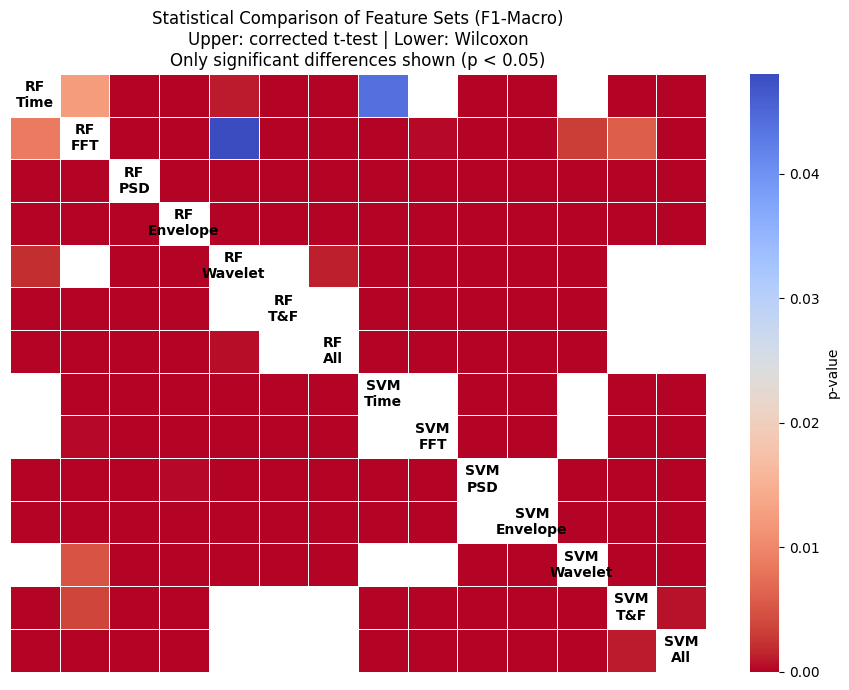

In [ ]:
heatmap_with_statical_test(BASE_PATH_CWRU12k, feature_sets_cwru12k, metric_name="F1-Macro", metric="f1")

# CWRU 48K

In [ ]:
BASE_PATH_CWRU48k = "/home/vbbonella/mestrado/tese-mestrado/experiments_scripts/results_per_dataset/cwru48k"

feature_sets_cwru48k = {
    "RF\nTime": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_48K_time_20251031_191328",
    "RF\nFFT": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_48K_frequency_20251031_191708",
    "RF\nPSD": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_48K_psd_20251031_192837",
    "RF\nEnvelope": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_48K_spectral_envelope_20251031_193200",
    "RF\nWavelet": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_48K_wavelet_20251031_192414",
    "RF\nT&F": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_48K_time_and_frequency_20251031_192028",
    "RF\nAll": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_48K_all_20251031_193516",
    "SVM\nTime": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_48K_time_20251031_142332",
    "SVM\nFFT": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_48K_frequency_20251031_142354",
    "SVM\nPSD": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_48K_psd_20251031_142438",
    "SVM\nEnvelope": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_48K_spectral_envelope_20251031_142455",
    "SVM\nWavelet": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_48K_wavelet_20251031_142423",
    "SVM\nT&F": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_48K_time_and_frequency_20251031_142408",
    "SVM\nAll": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_48K_all_20251031_142511"
}


feature_sets_cwru48k_rf_svm = {
    "RF\nTime": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_48K_time_20251031_191328",
    "RF\nFFT": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_48K_frequency_20251031_191708",
    "RF\nPSD": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_48K_psd_20251031_192837",
    "RF\nEnvelope": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_48K_spectral_envelope_20251031_193200",
    "RF\nWavelet": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_48K_wavelet_20251031_192414",
    "SVM\nTime": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_48K_time_20251031_142332",
    "SVM\nFFT": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_48K_frequency_20251031_142354",
    "SVM\nPSD": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_48K_psd_20251031_142438",
    "SVM\nEnvelope": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_48K_spectral_envelope_20251031_142455",
    "SVM\nWavelet": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_48K_wavelet_20251031_142423",
}

feature_sets_cwru48k_rf= {
    "RF\nTime": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_48K_time_20251031_191328",
    "RF\nFFT": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_48K_frequency_20251031_191708",
    "RF\nPSD": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_48K_psd_20251031_192837",
    "RF\nEnvelope": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_48K_spectral_envelope_20251031_193200",
    "RF\nWavelet": "vibration_analysis_results_Vibration_Analysis_RF_CWRU_48K_wavelet_20251031_192414",
}


feature_sets_cwru48k_svm = {
    "SVM\nTime": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_48K_time_20251031_142332",
    "SVM\nFFT": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_48K_frequency_20251031_142354",
    "SVM\nPSD": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_48K_psd_20251031_142438",
    "SVM\nEnvelope": "vibration_analysis_results_Vibration_Analysis_SVM_CWRU_48K_spectral_envelope_20251031_142455",
}

In [ ]:
sets_cwru48k = [("SVM", feature_sets_cwru48k_svm), ("RF", feature_sets_cwru48k_rf), ("RF+SVM", feature_sets_cwru48k_rf_svm)]

for name, feature_set in sets_cwru48k:
    metricas_folds = ENSEMBLE_RESULTS(feature_set.values(), BASE_PATH_CWRU48k)

    # Exibindo os valores formatados
    scores_balan_acc = []
    scores_f1_macro = []
    for m in metricas_folds:
        scores_balan_acc.append(m['f1_macro'])
        scores_f1_macro.append(m['balanced_accuracy'])

    print(f"--- Resultados do ENSEMBLE {name} CWRU 48k ---")
    print("scores_f1_macro:", scores_f1_macro)
    print(f"Média F1 Macro: {np.mean(scores_balan_acc):.4f} Std: {np.std(scores_balan_acc):.4f}")
    print(f"Média Balanced Accuracy: {np.mean(scores_f1_macro):.4f} Std: {np.std(scores_f1_macro):.4f}\n")

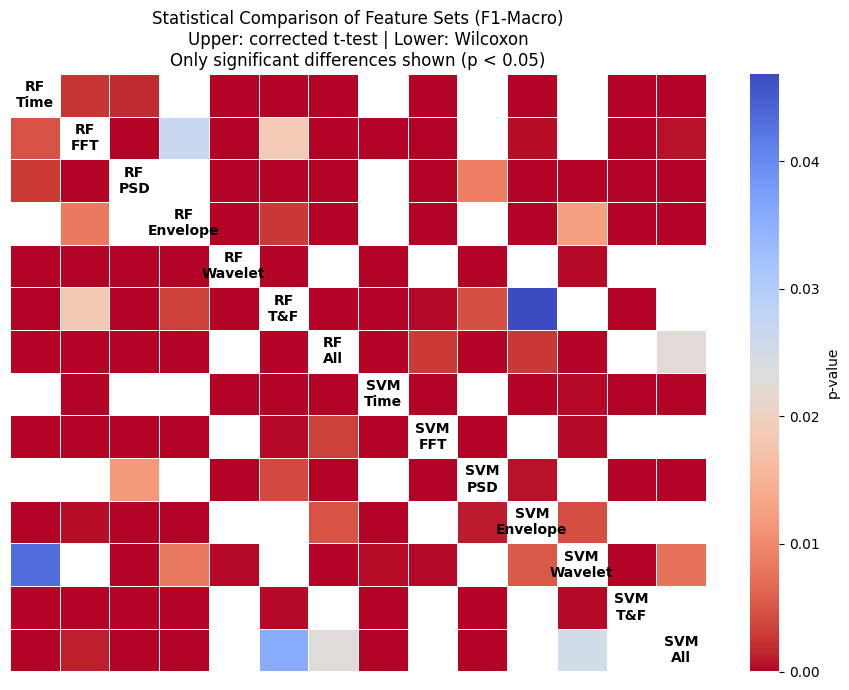

In [ ]:
heatmap_with_statical_test(BASE_PATH_CWRU48k, feature_sets_cwru48k, metric_name="F1-Macro", metric="f1")

# IMS

In [53]:
BASE_PATH_IMS = "/home/vbbonella/mestrado/tese-mestrado/experiments_scripts/results_per_dataset/ims"
feature_sets_ims = {
    "RF\nTime": "vibration_analysis_results_Vibration_Analysis_RF_IMS_time_20251101_003913.json",
    "RF\nFFT": "vibration_analysis_results_Vibration_Analysis_RF_IMS_frequency_20251101_004137.json",
    "RF\nPSD": "vibration_analysis_results_Vibration_Analysis_RF_IMS_psd_20251101_004804.json",
    "RF\nEnvelope": "vibration_analysis_results_Vibration_Analysis_RF_IMS_spectral_envelope_20251101_004958.json",
    "RF\nWavelet": "vibration_analysis_results_Vibration_Analysis_RF_IMS_wavelet_20251101_004336.json",
    "RF\nT&F": "vibration_analysis_results_Vibration_Analysis_RF_IMS_time_and_frequency__20260108_171751.json",
    "RF\nAll": "vibration_analysis_results_Vibration_Analysis_RF_IMS_all_20251101_005204.json",
    "SVM\nTime": "vibration_analysis_results_Vibration_Analysis_SVM_IMS_time_20251031_155210.json",
    "SVM\nFFT": "vibration_analysis_results_Vibration_Analysis_SVM_IMS_frequency_20251031_160430.json",
    "SVM\nPSD": "vibration_analysis_results_Vibration_Analysis_SVM_IMS_psd_20251031_163200.json",
    "SVM\nEnvelope": "vibration_analysis_results_Vibration_Analysis_SVM_IMS_spectral_envelope_20251031_163408.json",
    "SVM\nWavelet": "vibration_analysis_results_Vibration_Analysis_SVM_IMS_wavelet_20251031_160631.json",
    "SVM\nT&F": "vibration_analysis_results_Vibration_Analysis_SVM_IMS_time_and_frequency__20260108_165819.json",
    "SVM\nAll": "vibration_analysis_results_Vibration_Analysis_SVM_IMS_all_20251031_163640.json"
}

feature_sets_rf_svm_ims = {
    "RF\nTime": "vibration_analysis_results_Vibration_Analysis_RF_IMS_time_20251101_003913.json",
    "RF\nFFT": "vibration_analysis_results_Vibration_Analysis_RF_IMS_frequency_20251101_004137.json",
    "RF\nPSD": "vibration_analysis_results_Vibration_Analysis_RF_IMS_psd_20251101_004804.json",
    "RF\nEnvelope": "vibration_analysis_results_Vibration_Analysis_RF_IMS_spectral_envelope_20251101_004958.json",
    "RF\nWavelet": "vibration_analysis_results_Vibration_Analysis_RF_IMS_wavelet_20251101_004336.json",
    "SVM\nTime": "vibration_analysis_results_Vibration_Analysis_SVM_IMS_time_20251031_155210.json",
    "SVM\nFFT": "vibration_analysis_results_Vibration_Analysis_SVM_IMS_frequency_20251031_160430.json",
    "SVM\nPSD": "vibration_analysis_results_Vibration_Analysis_SVM_IMS_psd_20251031_163200.json",
    "SVM\nEnvelope": "vibration_analysis_results_Vibration_Analysis_SVM_IMS_spectral_envelope_20251031_163408.json",
    "SVM\nWavelet": "vibration_analysis_results_Vibration_Analysis_SVM_IMS_wavelet_20251031_160631.json",
}

feature_sets_svm_ims = {
    "SVM\nTime": "vibration_analysis_results_Vibration_Analysis_SVM_IMS_time_20251031_155210.json",
    "SVM\nFFT": "vibration_analysis_results_Vibration_Analysis_SVM_IMS_frequency_20251031_160430.json",
    "SVM\nPSD": "vibration_analysis_results_Vibration_Analysis_SVM_IMS_psd_20251031_163200.json",
    "SVM\nEnvelope": "vibration_analysis_results_Vibration_Analysis_SVM_IMS_spectral_envelope_20251031_163408.json",
    "SVM\nWavelet": "vibration_analysis_results_Vibration_Analysis_SVM_IMS_wavelet_20251031_160631.json",
}

feature_sets_rf_ims = {
    "RF\nTime": "vibration_analysis_results_Vibration_Analysis_RF_IMS_time_20251101_003913.json",
    "RF\nFFT": "vibration_analysis_results_Vibration_Analysis_RF_IMS_frequency_20251101_004137.json",
    "RF\nPSD": "vibration_analysis_results_Vibration_Analysis_RF_IMS_psd_20251101_004804.json",
    "RF\nEnvelope": "vibration_analysis_results_Vibration_Analysis_RF_IMS_spectral_envelope_20251101_004958.json",
    "RF\nWavelet": "vibration_analysis_results_Vibration_Analysis_RF_IMS_wavelet_20251101_004336.json",
}


In [56]:
sets_ims = [("SVM", feature_sets_svm_ims), ("RF", feature_sets_rf_ims), ("RF+SVM", feature_sets_rf_svm_ims)]

for name, feature_set in sets_ims:
    metricas_folds = ENSEMBLE_RESULTS_SINGLEROUND(feature_set.values(), BASE_PATH_IMS)

    # Exibindo os valores formatados
    scores_balan_acc = []
    scores_f1_macro = []
    for m in metricas_folds:
        scores_balan_acc.append(m['f1_macro'])
        scores_f1_macro.append(m['balanced_accuracy'])

    print(f"--- Resultados do ENSEMBLE {name} IMS ---")
    print("scores_f1_macro:", scores_f1_macro)
    print(f"Média F1 Macro: {np.mean(scores_balan_acc):.4f} ± {np.std(scores_balan_acc):.4f}")
    print(f"Média Balanced Accuracy: {np.mean(scores_f1_macro):.4f} ± {np.std(scores_f1_macro):.4f}\n")

--- Resultados do ENSEMBLE SVM IMS ---
scores_f1_macro: [0.1689921661328854, 0.15680903539737218, 0.15876181548316537, 0.14642001710863986, 0.1473094915424812, 0.15058760628481743, 0.14931879674099657, 0.15299490465017837, 0.14227427638842222, 0.14474533861523128, 0.14682419237866667, 0.14371087080250428, 0.2319799002146885, 0.19470381645422866, 0.1958850263936792]
Média F1 Macro: 0.0830 ± 0.0425
Média Balanced Accuracy: 0.1621 ± 0.0249

--- Resultados do ENSEMBLE RF IMS ---
scores_f1_macro: [0.2069708054082394, 0.16783866393406036, 0.17342334956350897, 0.22506839174816462, 0.18335660824768354, 0.19112313259197022, 0.23588375015519514, 0.2012988138521419, 0.18897910971617557, 0.23683078965803347, 0.19693239784495958, 0.1949862854948536, 0.18404795451114578, 0.1724987839447156, 0.1677310924369748]
Média F1 Macro: 0.1368 ± 0.0248
Média Balanced Accuracy: 0.1951 ± 0.0220

--- Resultados do ENSEMBLE RF+SVM IMS ---
scores_f1_macro: [0.2069708054082394, 0.16783866393406036, 0.173423349563508

# MFPT

In [58]:
BASE_PATH_MFPT = "/home/vbbonella/mestrado/tese-mestrado/experiments_scripts/results_per_dataset/mfpt"

feature_sets_MFPT = {
    "RF\nTime": "vibration_analysis_results_Vibration_Analysis_RF_MFPT_time_20251031_165628",
    "RF\nFFT": "vibration_analysis_results_Vibration_Analysis_RF_MFPT_frequency_20251031_170156",
    "RF\nPSD": "vibration_analysis_results_Vibration_Analysis_RF_MFPT_psd_20251031_171822",
    "RF\nEnvelope": "vibration_analysis_results_Vibration_Analysis_RF_MFPT_spectral_envelope_20251031_172352",
    "RF\nWavelet": "vibration_analysis_results_Vibration_Analysis_RF_MFPT_wavelet_20251031_171251",
    "RF\nT&F": "vibration_analysis_results_Vibration_Analysis_RF_MFPT_time_and_frequency_20251031_170724",
    "RF\nAll": "vibration_analysis_results_Vibration_Analysis_RF_MFPT_all_20251031_172924",
    "SVM\nTime": "vibration_analysis_results_Vibration_Analysis_SVM_MFPT_time_20251031_133852",
    "SVM\nFFT": "vibration_analysis_results_Vibration_Analysis_SVM_MFPT_frequency_20251031_134152",
    "SVM\nPSD": "vibration_analysis_results_Vibration_Analysis_SVM_MFPT_psd_20251031_135105",
    "SVM\nEnvelope": "vibration_analysis_results_Vibration_Analysis_SVM_MFPT_spectral_envelope_20251031_135402",
    "SVM\nWavelet": "vibration_analysis_results_Vibration_Analysis_SVM_MFPT_wavelet_20251031_134806",
    "SVM\nT&F": "vibration_analysis_results_Vibration_Analysis_SVM_MFPT_time_and_frequency_20251031_134456",
    "SVM\nAll": "vibration_analysis_results_Vibration_Analysis_SVM_MFPT_all_20251031_135702"
}

feature_sets_svm_rf_mfpt = {
    "RF\nTime": "vibration_analysis_results_Vibration_Analysis_RF_MFPT_time_20251031_165628",
    "RF\nFFT": "vibration_analysis_results_Vibration_Analysis_RF_MFPT_frequency_20251031_170156",
    "RF\nPSD": "vibration_analysis_results_Vibration_Analysis_RF_MFPT_psd_20251031_171822",
    "RF\nEnvelope": "vibration_analysis_results_Vibration_Analysis_RF_MFPT_spectral_envelope_20251031_172352",
    "RF\nWavelet": "vibration_analysis_results_Vibration_Analysis_RF_MFPT_wavelet_20251031_171251",
    "SVM\nTime": "vibration_analysis_results_Vibration_Analysis_SVM_MFPT_time_20251031_133852",
    "SVM\nFFT": "vibration_analysis_results_Vibration_Analysis_SVM_MFPT_frequency_20251031_134152",
    "SVM\nPSD": "vibration_analysis_results_Vibration_Analysis_SVM_MFPT_psd_20251031_135105",
    "SVM\nEnvelope": "vibration_analysis_results_Vibration_Analysis_SVM_MFPT_spectral_envelope_20251031_135402",
    "SVM\nWavelet": "vibration_analysis_results_Vibration_Analysis_SVM_MFPT_wavelet_20251031_134806",
}

feature_sets_rf_mfpt = {
    "RF\nTime": "vibration_analysis_results_Vibration_Analysis_RF_MFPT_time_20251031_165628",
    "RF\nFFT": "vibration_analysis_results_Vibration_Analysis_RF_MFPT_frequency_20251031_170156",
    "RF\nPSD": "vibration_analysis_results_Vibration_Analysis_RF_MFPT_psd_20251031_171822",
    "RF\nEnvelope": "vibration_analysis_results_Vibration_Analysis_RF_MFPT_spectral_envelope_20251031_172352",
    "RF\nWavelet": "vibration_analysis_results_Vibration_Analysis_RF_MFPT_wavelet_20251031_171251",
}

feature_sets_svm_mfpt = {
    "SVM\nTime": "vibration_analysis_results_Vibration_Analysis_SVM_MFPT_time_20251031_133852",
    "SVM\nFFT": "vibration_analysis_results_Vibration_Analysis_SVM_MFPT_frequency_20251031_134152",
    "SVM\nPSD": "vibration_analysis_results_Vibration_Analysis_SVM_MFPT_psd_20251031_135105",
    "SVM\nEnvelope": "vibration_analysis_results_Vibration_Analysis_SVM_MFPT_spectral_envelope_20251031_135402",
    "SVM\nWavelet": "vibration_analysis_results_Vibration_Analysis_SVM_MFPT_wavelet_20251031_134806",
}

In [60]:
sets_mfpt = [("SVM", feature_sets_svm_mfpt), ("RF", feature_sets_rf_mfpt), ("RF+SVM", feature_sets_svm_rf_mfpt)]

for name, feature_set in sets_mfpt:
    metricas_folds = ENSEMBLE_RESULTS(feature_set.values(), BASE_PATH_MFPT)

    # Exibindo os valores formatados
    scores_balan_acc = []
    scores_f1_macro = []
    for m in metricas_folds:
        scores_balan_acc.append(m['f1_macro'])
        scores_f1_macro.append(m['balanced_accuracy'])

    print(f"--- Resultados do ENSEMBLE {name} MFPT ---")
    print("scores_f1_macro:", scores_f1_macro)
    print(f"Média F1 Macro: {np.mean(scores_balan_acc):.4f} ± {np.std(scores_balan_acc):.4f}")
    print(f"Média Balanced Accuracy: {np.mean(scores_f1_macro):.4f} ± {np.std(scores_f1_macro):.4f}\n")

--- Resultados do ENSEMBLE SVM MFPT ---
scores_f1_macro: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.8333333333333333, 1.0]
Média F1 Macro: 0.9951 ± 0.0286
Média Balanced Accuracy: 0.9952 ± 0.0278

--- Resultados do ENSEMBLE RF MFPT ---
scores_f1_macro: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.5, 0.6666666666666666, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.5, 1.0, 1.0, 1.0, 1.0, 0.5, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.5, 1.0]
Média F1 Macro: 0.9131 ± 0.2174
Média Balanced Accuracy: 0.9333 ± 0.1652

--- Resultados do ENSEMBLE RF+SVM MFPT ---
scores_f1_macro: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.5, 0.6666666666666666, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.5, 1.0, 1.0, 1.0, 1.0, 0.5, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.5, 1.0]
Média F1 Macro: 0.9131 ± 0.2174
Média Balanced Accuracy: 0.9333 ± 0.1652



# PU

In [63]:
BASE_PATH_PU = "/home/vbbonella/mestrado/tese-mestrado/experiments_scripts/results_per_dataset/pu"

feature_sets_PU = {
    "RF\nTime": "vibration_analysis_results_Vibration_Analysis_RF_PU_time_20251031_194307",
    "RF\nFFT": "vibration_analysis_results_Vibration_Analysis_RF_PU_frequency_20251031_201944",
    "RF\nPSD": "vibration_analysis_results_Vibration_Analysis_RF_PU_psd_20251031_222708",
    "RF\nEnvelope": "vibration_analysis_results_Vibration_Analysis_RF_PU_spectral_envelope_20251031_225316",
    "RF\nWavelet": "vibration_analysis_results_Vibration_Analysis_RF_PU_wavelet_20251031_212544",
    "RF\nT&F": "vibration_analysis_results_Vibration_Analysis_RF_PU_time_and_frequency_20251031_204524",
    "RF\nAll": "vibration_analysis_results_Vibration_Analysis_RF_PU_all_20251031_232354",
    "SVM\nTime": "vibration_analysis_results_Vibration_Analysis_SVM_PU_time_20251031_142743",
    "SVM\nFFT": "vibration_analysis_results_Vibration_Analysis_SVM_PU_frequency_20251031_143936",
    "SVM\nPSD": "vibration_analysis_results_Vibration_Analysis_SVM_PU_psd_20251031_151312",
    "SVM\nEnvelope": "vibration_analysis_results_Vibration_Analysis_SVM_PU_spectral_envelope_20251031_152218",
    "SVM\nWavelet": "vibration_analysis_results_Vibration_Analysis_SVM_PU_wavelet_20251031_145636",
    "SVM\nT&F": "vibration_analysis_results_Vibration_Analysis_SVM_PU_time_and_frequency_20251031_144754",
    "SVM\nAll": "vibration_analysis_results_Vibration_Analysis_SVM_PU_all_20251031_153206"
}

feature_sets_svm_rf_pu = {
    "RF\nTime": "vibration_analysis_results_Vibration_Analysis_RF_PU_time_20251031_194307",
    "RF\nFFT": "vibration_analysis_results_Vibration_Analysis_RF_PU_frequency_20251031_201944",
    "RF\nPSD": "vibration_analysis_results_Vibration_Analysis_RF_PU_psd_20251031_222708",
    "RF\nEnvelope": "vibration_analysis_results_Vibration_Analysis_RF_PU_spectral_envelope_20251031_225316",
    "RF\nWavelet": "vibration_analysis_results_Vibration_Analysis_RF_PU_wavelet_20251031_212544",
    "SVM\nTime": "vibration_analysis_results_Vibration_Analysis_SVM_PU_time_20251031_142743",
    "SVM\nFFT": "vibration_analysis_results_Vibration_Analysis_SVM_PU_frequency_20251031_143936",
    "SVM\nPSD": "vibration_analysis_results_Vibration_Analysis_SVM_PU_psd_20251031_151312",
    "SVM\nEnvelope": "vibration_analysis_results_Vibration_Analysis_SVM_PU_spectral_envelope_20251031_152218",
    "SVM\nWavelet": "vibration_analysis_results_Vibration_Analysis_SVM_PU_wavelet_20251031_145636",
}

feature_sets_rf_pu = {
    "RF\nTime": "vibration_analysis_results_Vibration_Analysis_RF_PU_time_20251031_194307",
    "RF\nFFT": "vibration_analysis_results_Vibration_Analysis_RF_PU_frequency_20251031_201944",
    "RF\nPSD": "vibration_analysis_results_Vibration_Analysis_RF_PU_psd_20251031_222708",
    "RF\nEnvelope": "vibration_analysis_results_Vibration_Analysis_RF_PU_spectral_envelope_20251031_225316",
    "RF\nWavelet": "vibration_analysis_results_Vibration_Analysis_RF_PU_wavelet_20251031_212544",
}

feature_sets_svm_pu = {
    "SVM\nTime": "vibration_analysis_results_Vibration_Analysis_SVM_PU_time_20251031_142743",
    "SVM\nFFT": "vibration_analysis_results_Vibration_Analysis_SVM_PU_frequency_20251031_143936",
    "SVM\nPSD": "vibration_analysis_results_Vibration_Analysis_SVM_PU_psd_20251031_151312",
    "SVM\nEnvelope": "vibration_analysis_results_Vibration_Analysis_SVM_PU_spectral_envelope_20251031_152218",
    "SVM\nWavelet": "vibration_analysis_results_Vibration_Analysis_SVM_PU_wavelet_20251031_145636",
}

In [64]:
sets_pu = [("SVM", feature_sets_svm_pu), ("RF", feature_sets_rf_pu), ("RF+SVM", feature_sets_svm_rf_pu)]

for name, feature_set in sets_pu:
    metricas_folds = ENSEMBLE_RESULTS(feature_set.values(), BASE_PATH_PU)

    # Exibindo os valores formatados
    scores_balan_acc = []
    scores_f1_macro = []
    for m in metricas_folds:
        scores_balan_acc.append(m['f1_macro'])
        scores_f1_macro.append(m['balanced_accuracy'])

    print(f"--- Resultados do ENSEMBLE {name} PU ---")
    print("scores_f1_macro:", scores_f1_macro)
    print(f"Média F1 Macro: {np.mean(scores_balan_acc):.4f} ± {np.std(scores_balan_acc):.4f}")
    print(f"Média Balanced Accuracy: {np.mean(scores_f1_macro):.4f} ± {np.std(scores_f1_macro):.4f}\n")

--- Resultados do ENSEMBLE SVM PU ---
scores_f1_macro: [0.31711527736650286, 0.9623365762733194, 0.9705910364145659, 0.7501795735739316, 0.8151038402835038, 0.8507289915966387, 0.7021959186669603, 0.3823745628575953, 0.6943669935615164, 0.8338169911079067, 0.4397452731092437, 0.7311388626856634, 0.7012904807401816, 0.6414308531990202, 0.49097502181500874, 0.8281874694719114, 0.5723204096719976, 0.5128368926598879, 0.7313809523809525, 0.9248226438661173, 0.8132537459520457, 0.6362839974995234, 0.4828125, 0.8269890056740214, 0.5742761091910669, 0.39002759000932363, 0.8495176820728291, 0.9439575380831162, 0.4557098131479267, 0.9685407078103208, 0.8464382810622446, 0.6725697400045613]
Média F1 Macro: 0.6511 ± 0.2255
Média Balanced Accuracy: 0.6973 ± 0.1861

--- Resultados do ENSEMBLE RF PU ---
scores_f1_macro: [0.2552483963947298, 0.9627241076016402, 0.9662434761640506, 0.7756393653351752, 0.8309889037034438, 0.8845114346052886, 0.7361537014607649, 0.4035289106542788, 0.7821880861114026, 0